# 03 — Classification Layer Evaluation

Đánh giá layer classification của ShelfSense: SigLIP2 zero-shot narrowing (144 SKU → top-5) + LLM verify/escalation, trên eval set 150 dòng đã label thủ công.

Toàn bộ số liệu trong notebook này tính từ data tự thu thập (`data/scan_viz/eval_sample_selection.xlsx`, `data/scan_viz/review.xlsx`, `data/catalog/catalog_seed.csv`). Logic model (rank ứng viên, gọi LLM verify) nằm trong `src/`; notebook chỉ import và gọi lại các hàm đánh giá (`src/classification/benchmark/metrics.py`).

In [1]:
import sys, os
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# hàm eval thật, sống trong src/ -- notebook chỉ gọi lại, không tự viết công thức recall@k
from src.classification.benchmark.metrics import is_correct_at_k, compute_topk_accuracy

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

REPO_ROOT

PosixPath('/Users/realzoey/Project/shelf-stock-monitoring')

## 1. Problem statement

ShelfSense phát hiện box sản phẩm trên ảnh kệ (YOLO), rồi phải trả lời: **box này là SKU nào trong catalog?** Catalog hiện có 144 SKU cố định (closed-set) — không phải open-vocabulary classification.

Hai khó khăn cụ thể của bài toán này:

1. **Closed-set với nhiều SKU gần giống nhau.** Cùng brand nhiều vị/dung tích (Coca chai 390ml vs lon 320ml, Pepsi 390ml vs 600ml), hoặc khác brand nhưng bao bì gần giống (lon nước tăng lực, chai nước ngọt có ga). Similarity thuần túy (cosine trên embedding ảnh) không đủ phân biệt các cặp này một cách đáng tin cậy.

2. **Catalog-gap.** Trên kệ thật luôn có sản phẩm KHÔNG nằm trong 144 SKU đã seed (limited edition, brand chưa catalog hoá, dung tích lạ...). Với các case này, câu trả lời đúng duy nhất là "tôi không biết SKU này" -> ép model chọn đại 1 SKU gần nhất là sai, dù về mặt cosine similarity vẫn có thể có 1 candidate điểm khá cao.

Vì 2 lý do này, pipeline dùng kiến trúc 2 tầng (SigLIP2 narrowing + LLM verify) thay vì 1 model end-to-end, chi tiết ở mục 3. Notebook này đánh giá layer classification này độc lập với layer detection (YOLO) và layer gap-verify (xác nhận vùng trống thật sự thiếu hàng).

## 2. Data

Eval set: 150 dòng lấy stratified random theo category (không theo ảnh) từ pool test3–test19 + 3 ảnh kệ Sữa tự chụp mới (test20–22), label thủ công `true_sku_id` và đã audit lại bằng mắt 2 lượt (xem sheet `README` trong file gốc để biết đầy đủ quy trình). Gộp thành 3 batch theo thời điểm lấy mẫu:

- **Batch 1 (52 dòng):** Mì gói + Nước có ga, lấy đầu tiên, đã verify kỹ nhất.

- **Batch 2 (78 dòng):** mở rộng thêm cho 2 category trên.

- **Batch 3 (20 dòng):** riêng cho Sữa, từ 3 ảnh kệ sữa chụp mới (test20/21/22) vì pool test3-19 không đủ Sữa.

`category_proxy` trong file là suy từ `predicted_sku_id` của model, chỉ dùng để lấy mẫu cân bằng, KHÔNG phải nhãn thật. Category thật ở mục 5 trở đi suy từ `true_sku_id` đối chiếu `catalog_seed.csv`.

In [2]:
def load_eval_sample_selection(path="data/scan_viz/eval_sample_selection.xlsx"):
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb["eval_sample_selection"]
    rows = list(ws.iter_rows(values_only=True))
    header, data = rows[0], rows[1:]
    return pd.DataFrame(data, columns=header)


eval_df = load_eval_sample_selection()
catalog_df = pd.read_csv("data/catalog/catalog_seed.csv")
sku_to_category = dict(zip(catalog_df["sku_id"], catalog_df["Nhóm"]))
sku_to_name = dict(zip(catalog_df["sku_id"], catalog_df["name"]))

eval_df["true_category"] = eval_df["true_sku_id"].map(sku_to_category)  # NaN cho true_sku_id == "unknown"

print(f"eval set: {len(eval_df)} dòng | catalog: {len(catalog_df)} SKU")
eval_df["batch"].value_counts().sort_index().rename("n_rows").to_frame()

eval set: 150 dòng | catalog: 144 SKU


,n_rows
batch,
1,52
2,78
3,20


In [3]:
# breakdown theo category thật (từ true_sku_id) -- dòng "unknown" (catalog-gap/unidentifiable) tách riêng
category_counts = eval_df["true_category"].value_counts(dropna=False).rename(index={np.nan: "unknown (catalog-gap / unidentifiable-crop)"})
category_counts.rename("n_rows").to_frame()

,n_rows
true_category,
Mì/cháo/phở ăn liền,55
unknown (catalog-gap / unidentifiable-crop),52
Nước giải khát có ga,35
Sữa & sản phẩm từ sữa,8


## 3. Method

Pipeline classify (`src/pipeline/classify.py`) chạy 2 tầng cho mỗi crop:

**Tầng 1 — SigLIP2 zero-shot narrowing.** Embed crop bằng SigLIP2, so cosine similarity với embedding đã tính sẵn của cả 144 SKU trong catalog (`rank_candidates`), lấy top-5 điểm cao nhất. Đây là bước retrieval thuần túy, không dùng LLM — rẻ và nhanh, nhưng không đáng tin để tự quyết định cuối cùng.

**Tầng 2 — LLM verify (`escalate_to_llm_gemini`, Gemini 3.5 Flash Lite, fallback GPT 5.6 Luna/OpenRouter khi lỗi 503/timeout).** Đưa crop + ảnh reference thật của từng candidate trong top-5 cho LLM, yêu cầu so khớp brand/tên/bao bì gần như chính xác, hoặc trả lời `unknown` nếu không chắc. (`src/pipeline/llm_escalation.py`)

**Vì sao 2 tầng thay vì 1:**
- Cosine similarity một mình không phân biệt được các cặp bao bì gần giống (đã ghi trong docstring của `llm_escalation.py`: 1 lần benchmark trước đó bắt được case lon BOSS Cà Phê — vốn không có trong catalog — bị match nhầm bằng name-only reasoning khi không có ảnh reference).

- Cosine similarity không có cơ chế "abstain" đáng tin: score của 1 candidate catalog-gap vẫn có thể cao nếu bao bì cùng tông màu/hình dạng, nên không thể chỉ threshold theo điểm số để phát hiện catalog-gap.

- LLM verify thêm khả năng suy luận có ảnh reference thật + được dặn rõ ngưỡng match, nên xử lý được cả 2 vấn đề trên — đổi lại chi phí/latency cao hơn, nên chỉ chạy trên top-5 đã được tầng 1 lọc sẵn, không chạy trên cả 144 SKU.

**Lí do 2 tầng (SigLIP2 → LLM) thay vì chỉ dùng 1 model:**

**1. Vì sao không bỏ tầng LLM, chỉ dùng cosine similarity (SigLIP2) một mình?**
- Cosine similarity không phân biệt được các cặp bao bì gần giống nhau đủ tốt: đo thật cho thấy 2 SKU CÙNG hãng khác vị (Vinamilk có đường vs không đường) có cosine similarity 0.926 — CAO HƠN cả điểm giữa 2 SKU KHÁC hãng hình dạng giống nhau (Pepsi/7Up, 0.860) (docs/session-reports/2026-07-21-session-report-classification-and-gap-detection.md, Phần 4). Nếu chỉ dùng điểm cosine để quyết định, hệ thống dễ nhầm biến thể cùng hãng hơn là phân biệt 2 hãng khác nhau.

- Đã thử hướng rẻ hơn LLM trước khi chọn LLM: cộng thêm text-embedding (tên SKU) vào cosine score (cùng báo cáo, Phần 4) -> thất bại, điểm ra toàn nhiễu (0.001-0.18), không tách được đúng/sai, còn làm nhóm khác-hãng-giống-hình TỆ HƠN. Kết luận: đây là giới hạn thật của image-embedding cho domain/ngôn ngữ này, không phải lỗi cần vá thêm.

- Cosine similarity không có cách "từ chối trả lời" đáng tin khi sản phẩm thật không cótrong catalog (catalog-gap), score vẫn cao nếu bao bì cùng tông màu/hình dạng. Case thật: lon BOSS Cà Phê (không phải SKU nào trong catalog) từng bị ép match vào caphelon_hl_235 vì suy luận chỉ dựa tên, không có ảnh reference để so (src/pipeline/llm_escalation.py, dòng 7-16). Đây chính là gốc của finding 25% false-match rate ở notebook 03 — vẫn CHƯA hết hoàn toàn dù đã có LLM, chỉ giảm so với *chỉ dùng Cosine*.

**2. Vì sao không bỏ tầng SigLIP2, cho LLM nhìn thẳng cả 144 SKU?**
- Chi phí/độ trễ tăng theo quy mô catalog: mỗi lần gọi LLM phải đính kèm ảnh reference của TỪNG candidate (src/pipeline/llm_escalation.py, dòng 187-191) — gửi cả 144 ảnh cho mỗi box trong 1 ảnh scan (thường vài chục đến hơn trăm box) sẽ vừa chậm vừa tốn token, và tệ hơn: chi phí tăng tuyến tính mỗi khi catalog mở rộng thêm SKU mới.

- `rank_candidates()` lọc trước 144 → top-5 (src/pipeline/classify.py, dòng 40-49, mặc định `top_k=5`) bằng cosine math chạy local, không tốn API call — đúng như docstring của classify.py (dòng 15-22) ghi rõ: bước này "cheap... stays sequential", còn bước gọi LLM mới là network call phải chạy song song qua thread pool vì tốn I/O. Nhờ vậy chi phí LLM luôn cố định ở "so 5 ảnh", không phụ thuộc catalog có 144 hay 1000 SKU.

*Decision history:* thiết kế ban đầu (2026-07-21) từng cân nhắc "escalation-only", chỉ gọi LLM khi top1/top2 sát điểm nhau, giữ SigLIP2 làm lớp chính để tránh phụ thuộc API. Sau khi đo thực tế thấy ngay cả case "điểm số trông tự tin" vẫn sai (finding ở gạch đầu dòng đầu tiên phía trên) -> quyết định cuối (project note 08-14) đổi thành: LLM verify MỌI crop có embedding hợp lệ, không skip theo threshold nữa -> đổi tốc độ lấy độ tin cậy.

Mục 4 đo cụ thể tầng 1 (SigLIP2 narrowing) đạt được bao nhiêu % nếu dùng riêng, và tầng 2 (LLM verify) cải thiện được bao nhiêu so với đó.

### Load lại kết quả tầng 1 (top-5 candidates) từ log pipeline thật

Top-5 shortlist `src/pipeline/classify.py::rank_candidates`  được ghi lại khi pipeline chạy thật trên từng ảnh và log vào `data/scan_viz/review.xlsx` (cột `top5_candidates`) 

Notebook chỉ đọc lại log này qua `(sheet, index)`.

In [4]:
def load_review_lookup(path="data/scan_viz/review.xlsx"):
    """(sheet, index) -> row dict, đọc từ log pipeline thật (mọi sheet test1..test22)."""
    wb = openpyxl.load_workbook(path, data_only=True)
    lookup = {}
    for sheet in wb.sheetnames:
        rows = list(wb[sheet].iter_rows(values_only=True))
        if not rows:
            continue
        header, data = rows[0], rows[1:]
        df = pd.DataFrame(data, columns=header)
        for _, row in df.iterrows():
            lookup[(sheet, row["index"])] = row
    return lookup


def parse_top5(candidates_str):
    """'sku_a:0.73, sku_b:0.60, ...' -> [(sku_a, 0.73), (sku_b, 0.60), ...], thứ tự giữ nguyên (đã sort sẵn khi log)."""
    if not candidates_str:
        return []
    out = []
    for part in candidates_str.split(", "):
        sku_id, score = part.rsplit(":", 1)
        out.append((sku_id, float(score)))
    return out


review_lookup = load_review_lookup()
eval_keys = list(zip(eval_df["sheet"], eval_df["index"]))
missing_keys = [k for k in eval_keys if k not in review_lookup]
assert not missing_keys, f"{len(missing_keys)} dòng eval không tìm thấy log trong review.xlsx: {missing_keys[:5]}"

eval_df["top5"] = [parse_top5(review_lookup[k]["top5_candidates"]) for k in eval_keys]

# sanity check: predicted_sku_id trong eval set phải khớp log gốc -- nếu lệch, join sai key hoặc data đã bị sửa tay sau khi log.
# so sánh qua sentinel string thay vì == / != trực tiếp: pandas so 1 Series object với 1 list Python chứa None
# không coi None bằng None (đã verify riêng -- đây là 1 quirk có thật của pandas, không phải lỗi đánh máy),
# nên rất nhiều dòng catalog-gap (predicted_sku_id = None ở cả 2 phía) sẽ bị báo "lệch" oan nếu so trực tiếp.
_NONE_SENTINEL = "__NONE__"
eval_pred = eval_df["predicted_sku_id"].fillna(_NONE_SENTINEL)
review_pred = pd.Series([review_lookup[k]["predicted_sku_id"] for k in eval_keys], index=eval_df.index).fillna(_NONE_SENTINEL)
n_match = (eval_pred == review_pred).sum()
print(f"predicted_sku_id khớp giữa eval_sample_selection.xlsx và review.xlsx: {n_match}/{len(eval_df)}")

predicted_sku_id khớp giữa eval_sample_selection.xlsx và review.xlsx: 150/150


## 4. Baseline vs Improvement — recall@k của tầng SigLIP2

**Câu hỏi:** nếu chỉ dùng tầng 1 (SigLIP2 narrowing) làm quyết định cuối, không qua LLM verify, thì đúng bao nhiêu %? Và top-5 candidates mà LLM nhận được có chứa đáp án đúng đủ thường xuyên không (đây là trần trên — LLM không thể chọn đúng nếu SKU đúng không nằm trong top-5 nó thấy)?

Chỉ tính trên tập "solvable" — các dòng có đáp án thật trong catalog (`true_sku_id != "unknown"`). Dòng catalog-gap không có SKU đúng nào để so recall, tính vào đây sẽ làm sai lệch con số (xem mục 5 lý do đầy đủ).

`recall@1`/`recall@3`/`recall@5` gọi thẳng `compute_topk_accuracy` từ `src/classification/benchmark/metrics.py` — hàm này vốn viết cho benchmark catalog, ở đây dùng lại y nguyên với `true_sku_id` (string) thay cho category id (int), logic `in ranking[:k]` không đổi.

**Câu hỏi:** nếu dừng lại ở tầng 1 (SigLIP2 xếp hạng theo cosine similarity) và không qua LLM verify, chọn đại candidate điểm cao nhất thì đúng bao nhiêu %? 
Đây là recall@1. Và nếu nới rộng ra top-5 (đúng số candidate mà LLM thực sự được xem), đáp án đúng có nằm trong đó đủ thường xuyên không? Đây là recall@5 -> cũng là cận trên lý thuyết cho độ chính xác cuối cùng: LLM verify chỉ được chọn trong 5 candidate SigLIP2 đưa cho nó, nên nếu SKU đúng còn không lọt vào top-5 thì dù LLM suy luận giỏi cỡ nào cũng không thể chọn đúng.

Từ đó tách được 2 loại lỗi khác nhau, cần hướng sửa khác nhau:
- **Retrieval failure** (lỗi tầng 1): SKU đúng không lọt vào top-5 ngay từ đầu → muốn sửa phải cải thiện SigLIP2/catalog embedding, sửa prompt LLM không giúp được gì.

- **Reasoning failure** (lỗi tầng 2): SKU đúng CÓ trong top-5, nhưng LLM vẫn chọn sai candidate khác → muốn sửa phải cải thiện prompt/logic LLM, không phải retrieval.

Đây là lý do `verify_with_llm` trả ra `ranked` cùng đáp án cuối, để sau này tách được 2 loại lỗi trên khi review (src/pipeline/classify.py, dòng 89-98).

**Chỉ tính trên tập "solvable"**: các dòng có đáp án thật nằm trong catalog (`true_sku_id != "unknown"`). Lý do: recall@k hỏi "đáp án đúng có nằm trong ranking không" — dòng catalog-gap (sản phẩm thật không có trong catalog) không có đáp án đúng nào để tìm, câu hỏi này vô nghĩa với chúng. (Nhóm catalog-gap được xử lý riêng ở mục 5-6)

**Cách tính:**
`compute_topk_accuracy(per_item_rankings, true_categories, k)` (src/classification/benchmark/metrics.py, dòng 17-26) vốn viết cho benchmark catalog gốc — bên trong chỉ đơn giản là `true_category in ranking[:k]` cho từng dòng rồi lấy
trung bình (dòng 13-14, hàm `is_correct_at_k`). 

In [5]:
solvable_df = eval_df[eval_df["true_sku_id"] != "unknown"].copy()
n_solvable = len(solvable_df)

rankings = [[sku_id for sku_id, _score in top5] for top5 in solvable_df["top5"]]
true_skus = list(solvable_df["true_sku_id"])

recall_at_k = {k: compute_topk_accuracy(rankings, true_skus, k) for k in (1, 3, 5)}
final_pipeline_accuracy = (solvable_df["correct"] == "y").mean()

print(f"n solvable = {n_solvable}")
for k, v in recall_at_k.items():
    print(f"  SigLIP2 recall@{k}: {v:.1%}")
print(f"  Pipeline đầy đủ (post LLM verify), pure accuracy: {final_pipeline_accuracy:.1%}")

n solvable = 98
  SigLIP2 recall@1: 70.4%
  SigLIP2 recall@3: 87.8%
  SigLIP2 recall@5: 91.8%
  Pipeline đầy đủ (post LLM verify), pure accuracy: 85.7%


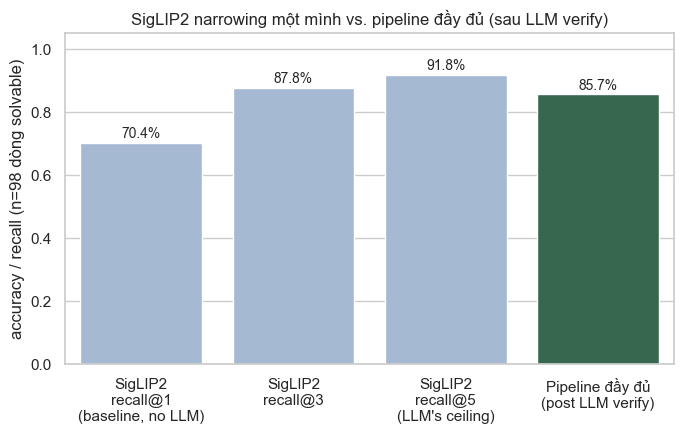

In [6]:
plot_df = pd.DataFrame(
    {
        "metric": ["SigLIP2\nrecall@1\n(baseline, no LLM)", "SigLIP2\nrecall@3", "SigLIP2\nrecall@5\n(LLM's ceiling)", "Pipeline đầy đủ\n(post LLM verify)"],
        "value": [recall_at_k[1], recall_at_k[3], recall_at_k[5], final_pipeline_accuracy],
        "kind": ["SigLIP2 alone", "SigLIP2 alone", "SigLIP2 alone", "Full pipeline"],
    }
)

fig, ax = plt.subplots(figsize=(7, 4.5))
palette = {"SigLIP2 alone": "#9fb8d9", "Full pipeline": "#2f6f4f"}
bars = sns.barplot(data=plot_df, x="metric", y="value", hue="kind", palette=palette, dodge=False, ax=ax, legend=False)
for bar, val in zip(bars.patches, plot_df["value"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.015, f"{val:.1%}", ha="center", fontsize=10)

ax.set_ylim(0, 1.05)
ax.set_ylabel(f"accuracy / recall (n={n_solvable} dòng solvable)")
ax.set_xlabel("")
ax.set_title("SigLIP2 narrowing một mình vs. pipeline đầy đủ (sau LLM verify)")
plt.tight_layout()
plt.show()

**Comment:** 
- `recall@1` là con số nếu bỏ hẳn LLM, dùng thẳng candidate cosine-similarity cao nhất của SigLIP2 làm câu trả lời. 
- `recall@5` là trần trên của cả hệ thống: LLM không bao giờ chọn đúng được nếu SKU thật không lọt vào top-5 mà tầng 1 đưa lên, nên đây cũng là chỉ số đo chất lượng retrieval của SigLIP2 độc lập với LLM.

Khoảng cách `recall@1` → pipeline đầy đủ chính là phần LLM verify improve so với việc chỉ lấy top-1 cosine similarity làm quyết định. Khoảng cách pipeline đầy đủ → `recall@5` là phần còn lại chưa khai thác hết — có thể do LLM verify quá thận trọng (trả unknown dù đáp án đúng có trong top-5) hoặc chọn nhầm 1 candidate khác trong top-5 thay vì đáp án đúng. Mục 6 phân tích cụ thể 2 kiểu lỗi này.

## 5. Final Results

- **(a) Pure classification accuracy:** loại hẳn dòng catalog-gap và unidentifiable-crop khỏi mẫu số. Đo: *khi bài toán có lời giải (SKU thật sự có trong catalog), model đoán đúng bao nhiêu %?* Đây là chất lượng phân loại thuần.

- **(b) Full end-to-end accuracy:** tính trên toàn bộ 150 dòng, kể cả catalog-gap: đúng khi model trả lời SKU đúng (case có đáp án thật) HOẶC model trả `unknown` đúng lúc (case catalog-gap).*

(b) luôn ≤ (a) về mặt cấu trúc, vì mẫu số (b) lớn hơn (150 vs n_solvable) trong khi (a) đã loại bỏ đúng những case khó nhất (catalog-gap) ra khỏi mẫu số. Chênh lệch giữa 2 số càng lớn thì catalog-gap detection (khả năng "biết mình không biết") càng là điểm yếu.

In [7]:
n_total = len(eval_df)
n_catalog_gap = int((eval_df["true_sku_id"] == "unknown").sum())

pure_correct = int((solvable_df["correct"] == "y").sum())
pure_accuracy = pure_correct / n_solvable

full_correct = int((eval_df["correct"] == "y").sum())
full_accuracy = full_correct / n_total

print(f"(a) Pure classification accuracy : {pure_correct}/{n_solvable} = {pure_accuracy:.1%}")
print(f"(b) Full end-to-end accuracy      : {full_correct}/{n_total} = {full_accuracy:.1%}")
print(f"    catalog-gap rate               : {n_catalog_gap}/{n_total} = {n_catalog_gap / n_total:.1%}")

(a) Pure classification accuracy : 84/98 = 85.7%
(b) Full end-to-end accuracy      : 121/150 = 80.7%
    catalog-gap rate               : 52/150 = 34.7%


In [8]:
MIN_RELIABLE_N = 20  # dưới ngưỡng này coi là "n quá nhỏ để kết luận", chỉ mang tính tín hiệu

cat_stats = (
    solvable_df.groupby("true_category")
    .agg(n=("correct", "size"), n_correct=("correct", lambda s: (s == "y").sum()))
    .assign(accuracy=lambda d: d["n_correct"] / d["n"])
    .sort_values("accuracy", ascending=False)
)
cat_stats["weak_signal"] = cat_stats["n"] < MIN_RELIABLE_N
cat_stats

,n,n_correct,accuracy,weak_signal
true_category,,,,
Nước giải khát có ga,35,32,0.914286,False
Mì/cháo/phở ăn liền,55,48,0.872727,False
Sữa & sản phẩm từ sữa,8,4,0.500000,True


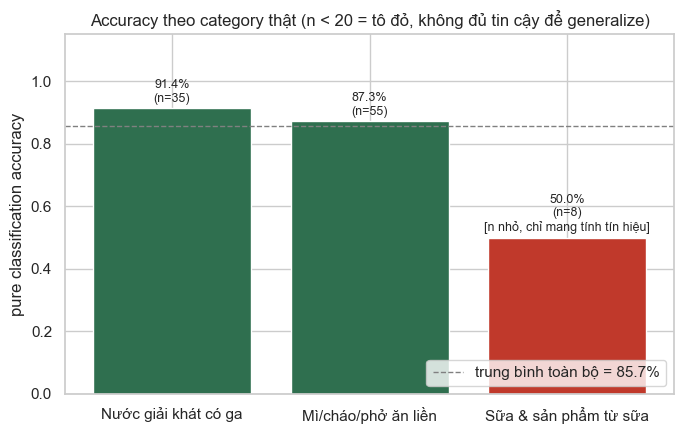

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ["#c0392b" if w else "#2f6f4f" for w in cat_stats["weak_signal"]]
bars = ax.bar(cat_stats.index, cat_stats["accuracy"], color=colors)

for bar, (_, row) in zip(bars, cat_stats.iterrows()):
    label = f"{row['accuracy']:.1%}\n(n={row['n']})"
    if row["weak_signal"]:
        label += "\n[n nhỏ, chỉ mang tính tín hiệu]"
    ax.text(bar.get_x() + bar.get_width() / 2, row["accuracy"] + 0.02, label, ha="center", fontsize=9)

ax.axhline(pure_accuracy, color="gray", linestyle="--", linewidth=1, label=f"trung bình toàn bộ = {pure_accuracy:.1%}")
ax.set_ylim(0, 1.15)
ax.set_ylabel("pure classification accuracy")
ax.set_xlabel("")
ax.set_title(f"Accuracy theo category thật (n < {MIN_RELIABLE_N} = tô đỏ, không đủ tin cậy để generalize)")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Error Analysis

**Câu hỏi:** trong các dòng catalog-gap (`true_sku_id == "unknown"`, sản phẩm thật không có SKU nào khớp trong catalog), model có đánh unknown đúng (trả `predicted_sku_id = None`) hay bị **force-match** với 1 SKU cụ thể dù không match?

Dùng trực tiếp `predicted_sku_id` (output thật của LLM verify) để tách 2 nhóm này.

In [10]:
gap_df = eval_df[eval_df["true_sku_id"] == "unknown"].copy()
gap_df["force_matched"] = gap_df["predicted_sku_id"].notna()

n_gap = len(gap_df)
n_force_matched = int(gap_df["force_matched"].sum())
n_correctly_abstained = n_gap - n_force_matched

print(f"Catalog-gap rows: {n_gap}")
print(f"  Đúng abstain (predicted_sku_id = None) : {n_correctly_abstained}/{n_gap} = {n_correctly_abstained / n_gap:.1%}")
print(f"  Force-match (ép ra 1 SKU sai)          : {n_force_matched}/{n_gap} = {n_force_matched / n_gap:.1%}")

Catalog-gap rows: 52
  Đúng abstain (predicted_sku_id = None) : 39/52 = 75.0%
  Force-match (ép ra 1 SKU sai)          : 13/52 = 25.0%


In [11]:
# ví dụ thật: sản phẩm thật (note) vs SKU model ép match sai
force_matched_df = gap_df[gap_df["force_matched"]].copy()
force_matched_df["predicted_sku_name"] = force_matched_df["predicted_sku_id"].map(sku_to_name)
force_matched_df[["sheet", "index", "note", "predicted_sku_id", "predicted_sku_name"]].reset_index(drop=True)

,sheet,index,note,predicted_sku_id,predicted_sku_name
0,test19,42,"World Cup limited packaging, 1.5L — catalog chưa có SKU Coca 1.5L nào",coca_org_chai_390,Nước ngọt Coca Cola chai 390ml
1,test3,34,"Crop cắt thiếu (không hoàn chỉnh), không đủ info để nhận diện — không có trong catalog",coca_zero_chai_390,Nước ngọt có ga Coca Cola Zero chai 390ml
2,test18,50,coca bản world cup 600ml,coca_org_chai_390,Nước ngọt Coca Cola chai 390ml
3,test18,75,"Chai vàng có hình lá trà + quả tròn cam/vàng + bong bóng 'Vitamin C', bị che góc trên, không thấ...",pepsi_lemon_chai_320,Nước ngọt Pepsi không calo vị chanh chai 390ml
4,test19,13,7Up vị Chanh Bạc Hà (Mint) — không phải Sprite; catalog chỉ có sprite_lon_320 (chanh thường) và ...,sprite_lon_320,Nước ngọt Sprite hương chanh lon 320ml
5,test19,40,Pepsi chanh không calo 1.5L,pepsi_lemon_chai_320,Nước ngọt Pepsi không calo vị chanh chai 390ml
6,test19,41,coca bản world cup 1.5l,coca_org_chai_390,Nước ngọt Coca Cola chai 390ml
7,test21,31,"catalog-gap: cũng là 1 sản phẩm hương dâu (dòng Thạch Trái Cây) của YoMost, nhưng không phải loạ...",yomost_dau,Sữa chua uống hương dâu YoMost 170ml
8,test21,58,"unidentifiable-crop: crop chỉ chụp mặt sau (bảng thành phần/dinh dưỡng, mã vạch), không thấy log...",dalatmilk_less_180,Sữa tươi tiệt trùng ít đường Dalat Milk 180ml
9,test21,19,catalog-gap: bao bì nâu 180ml với mascot bé trai vận động viên leo bục — không phải hình ảnh Mil...,milo_org_180,Sữa lúa mạch Milo 180ml


Vài ví dụ cụ thể đọc từ bảng trên (sản phẩm thật vs SKU bị đoán nhầm):

- Lon **7Up vị Chanh Bạc Hà** (Mint) — catalog chỉ có `sprite_lon_320` (Sprite chanh thường, không có vị bạc hà) — model vẫn match sang Sprite vì bao bì cùng tông xanh lá/lon tương tự.

- **Coca-Cola bản World Cup** (390ml và 1.5L) — catalog chỉ có bản thường `coca_org_chai_390` — model bỏ qua chi tiết bao bì limited-edition, match theo brand + hình dáng chai.

- **Pepsi chanh không calo 1.5L** — catalog chỉ có bản `pepsi_lemon_chai_320` (chai nhỏ hơn) — model match đúng brand/vị nhưng bỏ qua sai lệch dung tích.

Cả 3 ví dụ đều rơi vào cùng 1 pattern: 
- Match đúng brand + product line

- Bypass chi tiết phân biệt (vị, bao bì limited edition, dung tích), đúng loại lỗi mà prompt LLM verify đã cố ngăn ("packaging design match almost exactly") nhưng vẫn lọt qua ở các case biến thể khó.

Giờ đến các lỗi thật trên tập solvable (`correct == "n"` khi `true_sku_id` có đáp án thật trong catalog) — tách riêng 2 kiểu: **quá thận trọng** (model trả `unknown` dù có đáp án đúng) và **đoán sai SKU khác**.

In [12]:
solvable_errors = solvable_df[solvable_df["correct"] == "n"].copy()
solvable_errors["true_sku_name"] = solvable_errors["true_sku_id"].map(sku_to_name)
solvable_errors["predicted_sku_name"] = solvable_errors["predicted_sku_id"].map(sku_to_name)
solvable_errors["error_type"] = np.where(solvable_errors["predicted_sku_id"].isna(), "over-cautious (trả unknown dù có đáp án)", "wrong SKU (đoán sang SKU khác)")

n_over_cautious = int((solvable_errors["error_type"] == "over-cautious (trả unknown dù có đáp án)").sum())
n_wrong_sku = int((solvable_errors["error_type"] == "wrong SKU (đoán sang SKU khác)").sum())
print(f"Lỗi thật trên tập solvable: {len(solvable_errors)}")
print(f"  over-cautious : {n_over_cautious}")
print(f"  wrong SKU     : {n_wrong_sku}")

solvable_errors[["sheet", "index", "true_sku_id", "true_sku_name", "predicted_sku_id", "predicted_sku_name", "error_type"]].reset_index(drop=True)

Lỗi thật trên tập solvable: 14
  over-cautious : 8
  wrong SKU     : 6


,sheet,index,true_sku_id,true_sku_name,predicted_sku_id,predicted_sku_name,error_type
0,test8,61,phuhuong_suonheo_goi,Miến Phú Hương sườn heo gói 58g,None,NaN,over-cautious (trả unknown dù có đáp án)
1,test9,42,phuhuong_suonheo_goi,Miến Phú Hương sườn heo gói 58g,None,NaN,over-cautious (trả unknown dù có đáp án)
2,test19,19,pepsi_org_chai_600,Nước ngọt Pepsi Cola chai 600ml,pepsi_org_chai_390,Nước ngọt Pepsi Cola chai 390ml,wrong SKU (đoán sang SKU khác)
3,test10,13,siukay_haisan_goi,Mì hải sản SiuKay gói 128g\n,None,NaN,over-cautious (trả unknown dù có đáp án)
4,test6,18,indomie_caynong,Mì xào cay nồng Indomie gói 85g,None,NaN,over-cautious (trả unknown dù có đáp án)
5,test8,55,udon_sukisuki_tron,Mì Udon Sưkisưki trộn hương vị bò xốt teriyaki gói 82g,None,NaN,over-cautious (trả unknown dù có đáp án)
6,test9,17,indomie_caynong,Mì xào cay nồng Indomie gói 85g,indomie_dacbiet,Mì xào khô đặc biệt Indomie gói 85g,wrong SKU (đoán sang SKU khác)
7,test9,41,phuhuong_suonheo_goi,Miến Phú Hương sườn heo gói 58g,None,NaN,over-cautious (trả unknown dù có đáp án)
8,test18,4,coca_org_can_320,Lon nước ngọt Coca Cola 320ml,None,NaN,over-cautious (trả unknown dù có đáp án)
9,test4,20,pepsi_org_chai_600,Nước ngọt Pepsi Cola chai 600ml,pepsi_org_chai_390,Nước ngọt Pepsi Cola chai 390ml,wrong SKU (đoán sang SKU khác)


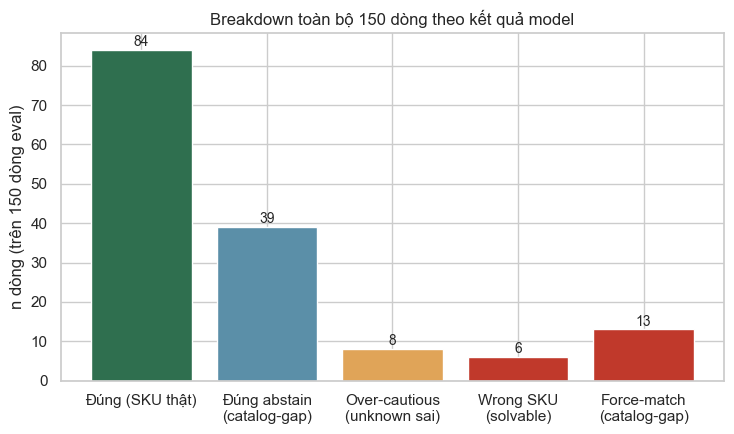

In [13]:
outcome_counts = pd.Series(
    {
        "Đúng (SKU thật)": pure_correct,
        "Đúng abstain\n(catalog-gap)": n_correctly_abstained,
        "Over-cautious\n(unknown sai)": n_over_cautious,
        "Wrong SKU\n(solvable)": n_wrong_sku,
        "Force-match\n(catalog-gap)": n_force_matched,
    }
)
assert outcome_counts["Đúng (SKU thật)"] + outcome_counts["Over-cautious\n(unknown sai)"] + outcome_counts["Wrong SKU\n(solvable)"] == n_solvable
assert outcome_counts["Đúng abstain\n(catalog-gap)"] + outcome_counts["Force-match\n(catalog-gap)"] == n_gap
assert outcome_counts.sum() == n_total

fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = ["#2f6f4f", "#5b8fa8", "#e0a458", "#c0392b", "#c0392b"]
bars = ax.bar(outcome_counts.index, outcome_counts.values, color=colors)
for bar, v in zip(bars, outcome_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v), ha="center", fontsize=10)

ax.set_ylabel("n dòng (trên 150 dòng eval)")
ax.set_title("Breakdown toàn bộ 150 dòng theo kết quả model")
plt.tight_layout()
plt.show()

**Comment:**
- 2 nhóm đỏ (over-cautious + wrong SKU trên solvable, force-match trên catalog-gap) là toàn bộ lỗi thật của hệ thống. Force-match trên catalog-gap là nhóm đáng chú ý nhất, model hallucination và chọn hẳn 1 SKU cụ thể trong khi đáp án đúng không tồn tại trong catalog, dù prompt LLM verify đã yêu cầu rõ "guessing wrong is worse than unknown". Phải tuning prompt vì chưa chặn được hết trên chính nhóm case nó được thiết kế để chặn.

## 7. Limitations

- **150 dòng chỉ target Mì gói, Nước ngọt và Sữa.** Trung bình chưa tới 1 sample/SKU nếu trải đều — số accuracy tổng và theo category phản ánh phân bố sản phẩm THẬT xuất hiện trên kệ đã chụp (weighted theo tần suất thật), không phải coverage đều theo từng SKU. Nhiều SKU trong catalog có thể chưa xuất hiện lần nào trong eval set.

- **Category Sữa: n rất nhỏ** — 8 dòng solvable, xem cờ đỏ ở chart mục 5. Con số 50% accuracy ở đây không đủ để kết luận Sữa yếu hơn Mì gói/Nước có ga một cách hệ thống; có thể chỉ là nhiễu thống kê từ mẫu nhỏ (batch 3, mới lấy 1 lần từ 3 ảnh). Không nên dùng số này để ưu tiên tune riêng cho Sữa mà không thu thêm data trước.

- **Domain gap giữa ảnh train và ảnh thật.** SigLIP2 embedding (và catalog reference images) không được fine-tune riêng trên ảnh kệ thật của ShelfSense — narrowing dựa trên pretrained zero-shot similarity. Ảnh eval set chụp trên kệ thật (góc nghiêng, ánh sáng, che khuất một phần) khác phân bố với ảnh catalog gốc (thường là ảnh sản phẩm sạch, chụp thẳng, nền trắng từ nguồn tgdd.vn) — đây nhiều khả năng là 1 nguyên nhân gốc của recall@1 chưa cao và của các case wrong-SKU nhầm variant cùng brand.

## 8. Next steps

1. **Tune lại prompt/ngưỡng LLM verify để giảm force-match trên catalog-gap** (mục 6: model force-match sai ~1/4 số case catalog-gap dù prompt đã yêu cầu ưu tiên `unknown`). Hướng cụ thể: thêm ví dụ few-shot minh hoạ đúng loại lỗi đang gặp (variant cùng brand khác vị/dung tích/limited-edition — xem 3 ví dụ ở mục 6) vào prompt, nhấn mạnh rằng match gần đúng brand/hình dạng KHÔNG đủ nếu vị/dung tích/ấn bản khác biệt rõ trên bao bì.

2. **Không tune riêng cho category Sữa dựa trên n=8 hiện tại** (mục 7) — trước tiên nên mở rộng eval set Sữa lên tương đương Mì gói/Nước có ga (~30-40 dòng) rồi mới đánh giá lại xem accuracy có thực sự thấp hơn hệ thống hay chỉ là nhiễu mẫu nhỏ.

3. **Đo lại recall@k (mục 4) sau khi retrain/fine-tune embedding** nếu có kế hoạch fine-tune SigLIP2 trên ảnh kệ thật — đây là baseline để so sánh trước/sau, tách riêng được cải thiện đến từ retrieval (tầng 1) hay từ LLM verify (tầng 2).

4. **Theo dõi catalog-gap rate theo thời gian** khi catalog được bổ sung thêm SKU mới từ chính các note catalog-gap đã thu thập được (mục 6 liệt kê khá nhiều sản phẩm lặp lại: nước tăng lực, TH true Yogurt biến thể, Ovaltine...) — mỗi SKU thêm vào catalog trực tiếp giảm catalog-gap rate và tăng full end-to-end accuracy, không cần đụng đến model.